# Predictive Modeling

**Purpose:** Build a Logistic Regression model to predict customer delinquency, evaluate its performance, and identify the features that drive collections risk.

In [1]:
# import os

# PROCESSED_DIR = "../data/processed"

# files = ["X_train.csv", "X_test.csv", "y_train.csv", "y_test.csv"]

# for f in files:
#     path = os.path.join(PROCESSED_DIR, f)
#     if os.path.exists(path):
#         print(f"FOUND    : {f}")
#     else:
#         print(f"MISSING  : {f}")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,  # to give precision/ recall/ F1
    confusion_matrix,  # shows correct vs incorrect predictions
    accuracy_score  # gives overall accuracy %
)

PROCESSED_DIR = "../data/processed"
FIGURES_DIR   = "../reports/figures"

# Load train/test sets saved in Feature Engineering notebook
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train.csv"))
X_test  = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train.csv")).squeeze()
y_test  = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze()

print(f"Training set : {X_train.shape[0]:,} records")
print(f"Test set     : {X_test.shape[0]:,} records")
print("Data loaded and ready for modeling.")

Training set : 24,000 records
Test set     : 6,000 records
Data loaded and ready for modeling.


In [3]:
# Building and training Logistic Regression model

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully.")
print(f"Iterations run : {model.n_iter_[0]}")

Model trained successfully.
Iterations run : 8


### Evaluating the Model

In [6]:
# Generate predictions
y_pred = model.predict(X_test) #run the trained model against the 6000 unseen set

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.1f}%")
print()

# Detailed performance breakdown
print("Classification Report:")
print("-" * 50)
print(classification_report(y_test, y_pred,         # Breaks down in - Precison, Recall, F1 & Support
      target_names=["Not Delinquent", "Delinquent"]))

# Metrics
# Precision (of predicted delinquent, how many actually were)
# Recall (of actual delinquent, how many did we catch)
# F1 (balance of both)
# Support (actual count per class)

Model Accuracy: 81.0%

Classification Report:
--------------------------------------------------
                precision    recall  f1-score   support

Not Delinquent       0.82      0.97      0.89      4687
    Delinquent       0.69      0.23      0.35      1313

      accuracy                           0.81      6000
     macro avg       0.76      0.60      0.62      6000
  weighted avg       0.79      0.81      0.77      6000



### Confusion Matrix

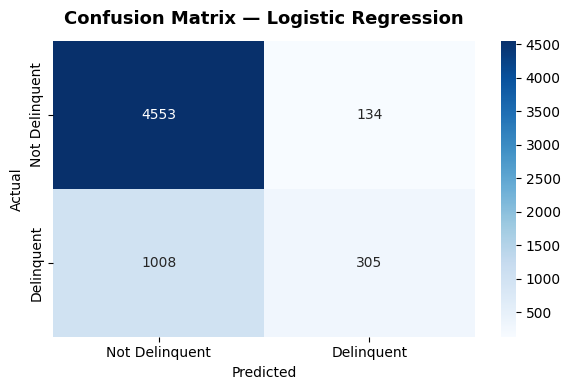

Confusion matrix saved.


In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Delinquent", "Delinquent"],
    yticklabels=["Not Delinquent", "Delinquent"]
)

ax.set_title("Confusion Matrix — Logistic Regression",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "section4_confusion_matrix.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved.")

### Feature Importance

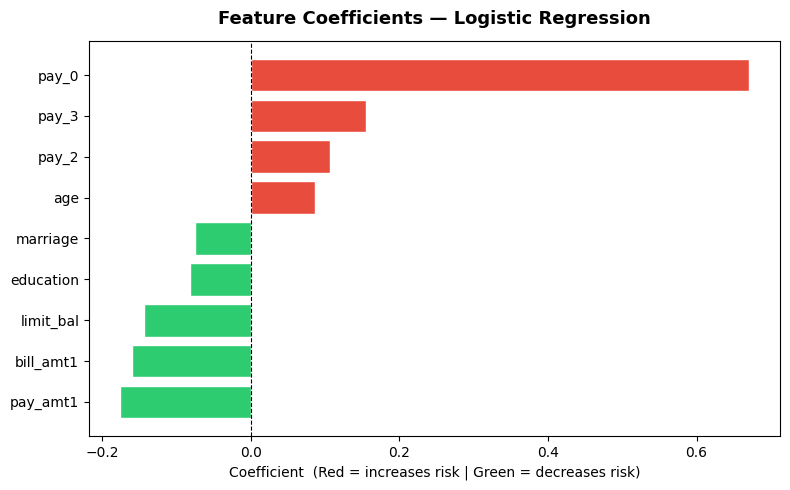

Feature importance chart saved.


In [9]:
features     = X_train.columns.tolist()
coefficients = model.coef_[0] # Positive- pushes towards delinquent, Negative- pushes away from delinquent

coef_df = pd.DataFrame({
    "feature"    : features,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#e74c3c" if c > 0 else "#2ecc71" for c in coef_df["coefficient"]]

ax.barh(coef_df["feature"], coef_df["coefficient"],
        color=colors, edgecolor="white")
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Feature Coefficients — Logistic Regression",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Coefficient  (Red = increases risk | Green = decreases risk)")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "section4_feature_importance.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Feature importance chart saved.")

### Key Insight from Feature Coefficients
- Payment status columns are the strongest drivers of delinquency risk
- Higher credit limit reduces risk — consistent with Section 2 heatmap findings
- Demographic features contribute but are weaker signals than payment behavior